<a href="https://colab.research.google.com/github/omarvlo/maquinas-escuchan-gaia2026/blob/main/demos_las_maquinas_escuchan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ¿Las máquinas escuchan?
### IA, señales y música — demos en vivo

**GAIA — Club de Inteligencia Artificial, ESCOM-IPN** · 11 de septiembre de 2026
Dr. Omar Velázquez López · IIMAS-UNAM

---

El notebook sigue las tres generaciones del procesamiento de audio:

| Parte | Concepto | Quién decide la representación | Cómputo |
|---|---|---|---|
| 1 | La señal | — | CPU |
| 2 | **Gen. de Ingeniería de características** | el humano, todo | CPU |
| 3 | **Gen. de Aprendizaje profundo** | la máquina aprende las features | GPU |
| 4 | **Gen. de Modelos fundacionales** | la máquina aprende sin etiquetas | GPU |
| 5 | Un puente a nuestra investigación | | |

> **Antes de la charla:** `Entorno de ejecución → Cambiar tipo de entorno → T4 GPU`,
> y ejecuta todo una vez. Las partes 3 y 4 descargan datos y pesos; si el wifi falla
> en vivo, ya tendrás las salidas en pantalla.

## Parte 0 — Preparación y audio

Cadena de respaldo: si una fuente falla, pasa a la siguiente. Nunca se queda sin audio.

In [ ]:
import numpy as np, matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, hilbert
from IPython.display import Audio, display

SR = 22050
plt.rcParams.update({"font.size": 13, "axes.spines.top": False,
                     "axes.spines.right": False})

def _sintetico(sr=SR, seg=8):
    """Último recurso: acordes sintetizados. Nunca falla, no descarga nada."""
    def midi_hz(m): return 440.0 * 2 ** ((m - 69) / 12)
    def nota(f0, dur=1.6):
        t = np.arange(int(dur * sr)) / sr
        env = np.exp(-3.0 * t) * (1 - np.exp(-200 * t))
        return env * sum((1 / h) * np.sin(2 * np.pi * f0 * h * t) for h in range(1, 9))
    acordes = [[48,55,64,72],[45,52,60,69],[50,57,65,74],[43,50,59,67],
               [48,55,64,72],[41,48,57,65],[46,53,62,70],[48,55,64,72]]
    x = np.zeros(int(seg * sr) + sr)
    for i, ac in enumerate(acordes):
        s = sum(nota(midi_hz(m)) for m in ac)
        x[int(i*sr):int(i*sr)+len(s)] += s
    x = x[:int(seg * sr)]
    return 0.85 * x / np.abs(x).max()

def cargar_audio(clave="nutcracker", dur=10.0, sr=SR):
    """1) clip real de librosa  2) archivo local  3) síntesis."""
    try:
        import librosa
        ruta = librosa.example(clave)
        y, _ = librosa.load(ruta, sr=sr, mono=True, duration=dur)
        return 0.9 * y / np.abs(y).max(), f"librosa: '{clave}'"
    except Exception as e:
        print(f"[aviso] no se pudo traer '{clave}' ({type(e).__name__}). Uso síntesis.")
        return _sintetico(sr, int(dur)), "sintético"

x, FUENTE = cargar_audio("nutcracker", dur=14.0)
print(f"Fuente: {FUENTE} | {len(x)/SR:.1f} s | {SR} Hz")
display(Audio(x, rate=SR))

from scipy.io import wavfile

def exportar(y, nombre, sr=SR):
    """WAV de 16 bits, normalizado. Compatible con PowerPoint y Keynote."""
    d = (0.9 * y / np.abs(y).max() * 32767).astype(np.int16)
    wavfile.write(nombre, sr, d)
    print(f"  guardado: {nombre}  ({len(d)/sr:.1f} s)")

exportar(x, "00_original.wav")

Fuente: librosa: 'nutcracker' | 14.0 s | 22050 Hz


  guardado: 00_original.wav  (14.0 s)


## Parte 1 — Para la computadora, la música es una lista de números

Eso es literalmente todo lo que recibe. Ninguna noción de nota, de instrumento,
de compás. Números.

Primeros 8 valores: [ 1.0e-05  3.0e-05 -3.0e-05  3.0e-05  7.0e-05 -2.0e-05 -1.1e-04 -1.5e-04]
Un segundo de música = 22,050 números


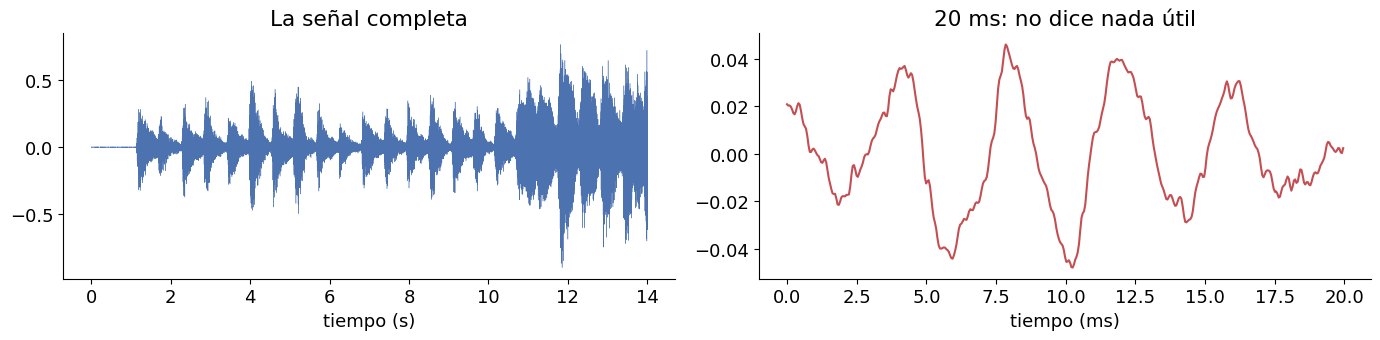

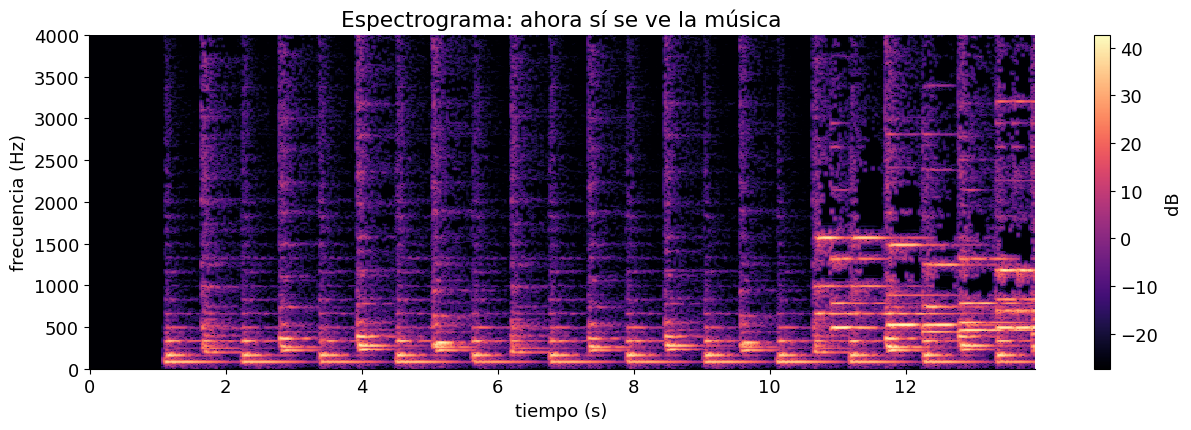

In [ ]:
print("Primeros 8 valores:", np.round(x[:8], 5))
print(f"Un segundo de música = {SR:,} números")

t = np.arange(len(x)) / SR
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 3.6))
a1.plot(t, x, lw=0.3, color="#4C72B0")
a1.set_xlabel("tiempo (s)"); a1.set_title("La señal completa")

ini = int(len(x) * 0.4)
tr = x[ini:ini + int(0.020 * SR)]
a2.plot(np.arange(len(tr)) / SR * 1000, tr, color="#C44E52")
a2.set_xlabel("tiempo (ms)"); a2.set_title("20 ms: no dice nada útil")
plt.tight_layout(); plt.show()

def stft_mag(x, n_fft=2048, hop=512):
    ven = np.hanning(n_fft)
    n = 1 + (len(x) - n_fft) // hop
    return np.stack([np.abs(np.fft.rfft(x[i*hop:i*hop+n_fft] * ven))
                     for i in range(n)], axis=1)

S = stft_mag(x)
frecs = np.fft.rfftfreq(2048, 1 / SR)
S_db = 20 * np.log10(S + 1e-6)

plt.figure(figsize=(13, 4.5))
plt.pcolormesh(np.arange(S.shape[1]) * 512 / SR, frecs, S_db,
               shading="auto", cmap="magma", vmin=S_db.max() - 70)
plt.ylim(0, 4000); plt.xlabel("tiempo (s)"); plt.ylabel("frecuencia (Hz)")
plt.title("Espectrograma: ahora sí se ve la música"); plt.colorbar(label="dB")
plt.tight_layout(); plt.show()

## Parte 2 — Primera generación: ingeniería de características

Durante décadas, el trabajo consistía en **diseñar a mano** la representación.
El espectrograma reparte sus canales linealmente: la misma resolución en 100 Hz
que en 7000 Hz. El oído no funciona así.

Existen varias propuestas de cómo espaciar los canales para imitarlo:

| escala | origen |
|---|---|
| **Mel** | experimentos de percepción de altura, 1937 |
| **ERB** | ancho de banda de los filtros auditivos (Glasberg y Moore, 1990) |
| **Greenwood** | posición física a lo largo de la cóclea, 1961 |
| lineal | sin modelo auditivo, como referencia |

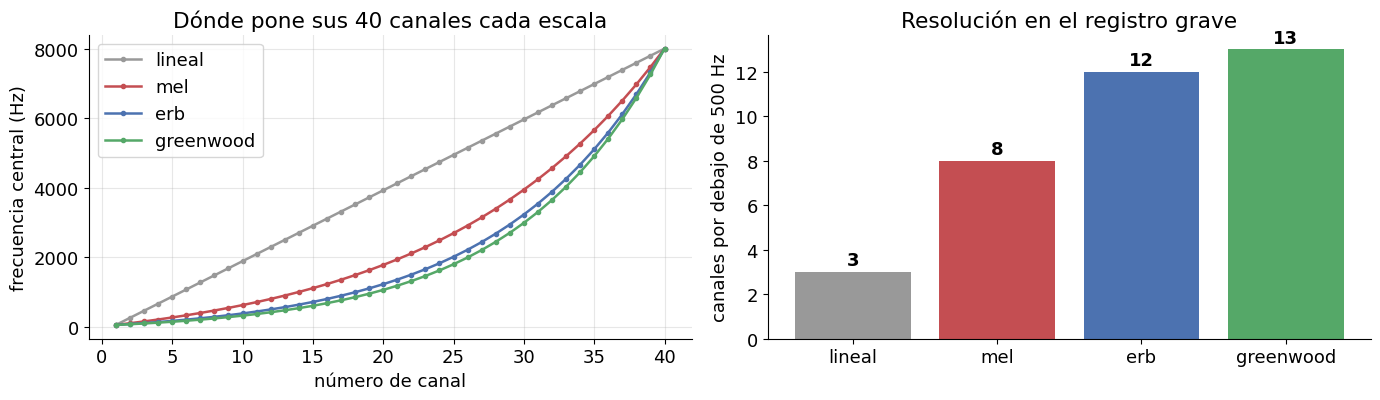

Con 40 canales, ¿cuántos caen bajo 500 Hz?  lineal=3   mel=8   erb=12   greenwood=13


In [ ]:
def hz_mel(f): return 2595 * np.log10(1 + f / 700)
def mel_hz(m): return 700 * (10 ** (m / 2595) - 1)
def hz_erb(f): return 21.4 * np.log10(4.37 * f / 1000 + 1)
def erb_hz(e): return (10 ** (e / 21.4) - 1) * 1000 / 4.37
def gw_hz(u):  return 165.4 * (10 ** (2.1 * u) - 0.88)      # Greenwood, humano
def hz_gw(f):  return np.log10(f / 165.4 + 0.88) / 2.1

def centros(escala, n, fmin=50, fmax=8000):
    ida = {"mel": (hz_mel, mel_hz), "erb": (hz_erb, erb_hz), "greenwood": (hz_gw, gw_hz)}
    if escala == "lineal":
        return np.linspace(fmin, fmax, n)
    f, g = ida[escala]
    return g(np.linspace(f(fmin), f(fmax), n))

N = 40
cols = {"lineal": "#999999", "mel": "#C44E52", "erb": "#4C72B0", "greenwood": "#55A868"}

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.2))
for e, c in cols.items():
    a1.plot(range(1, N+1), centros(e, N), "o-", color=c, label=e, ms=3, lw=1.8)
a1.set_xlabel("número de canal"); a1.set_ylabel("frecuencia central (Hz)")
a1.set_title(f"Dónde pone sus {N} canales cada escala"); a1.legend(); a1.grid(alpha=.3)

bajos = {e: int((centros(e, N) < 500).sum()) for e in cols}
a2.bar(list(bajos), list(bajos.values()), color=[cols[e] for e in bajos])
for i, (e, v) in enumerate(bajos.items()):
    a2.text(i, v + .3, str(v), ha="center", fontweight="bold")
a2.set_ylabel("canales por debajo de 500 Hz")
a2.set_title("Resolución en el registro grave")
plt.tight_layout(); plt.show()

print(f"Con {N} canales, ¿cuántos caen bajo 500 Hz?  " +
      "   ".join(f"{e}={v}" for e, v in bajos.items()))

### El mismo audio, visto por tres bancos distintos

El mismo fragmento, el mismo número de canales,
y **tres formas distintas de repartirlos**.

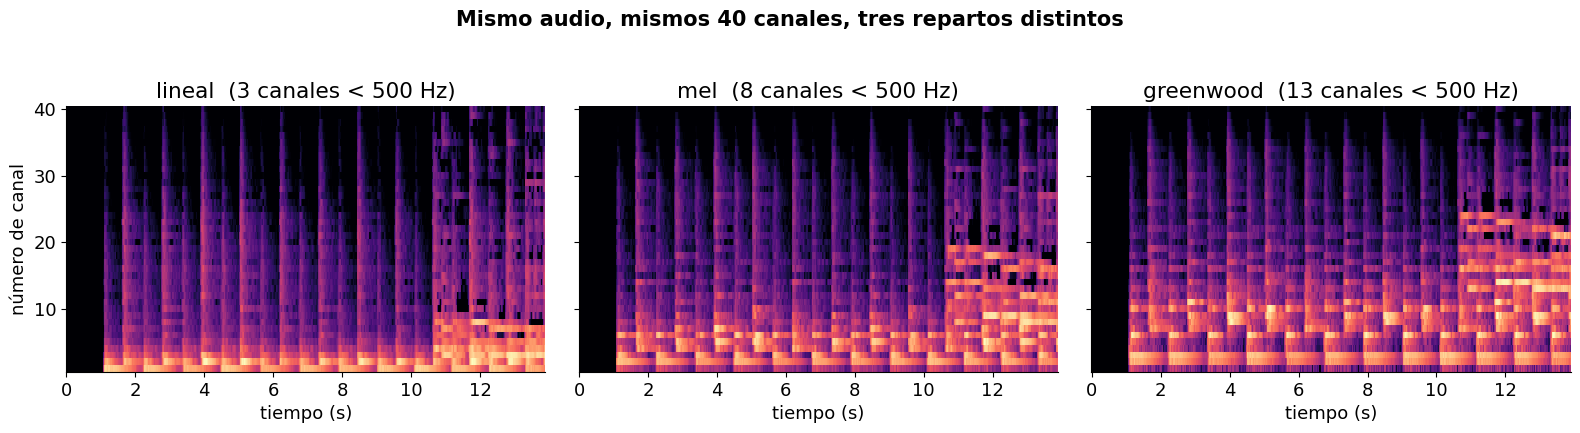

In [ ]:
def matriz_banco(fc, n_fft=2048, sr=SR):
    """Banco de filtros triangulares sobre los bins de la STFT."""
    fbins = np.fft.rfftfreq(n_fft, 1 / sr)
    med = np.sqrt(fc[:-1] * fc[1:])
    lo = np.concatenate([[fc[0]**2 / med[0]], med])
    hi = np.concatenate([med, [fc[-1]**2 / med[-1]]])
    W = np.zeros((len(fc), len(fbins)))
    for i, (l, c, h) in enumerate(zip(lo, fc, hi)):
        W[i] = np.clip(np.minimum((fbins - l) / max(c - l, 1e-9),
                                  (h - fbins) / max(h - c, 1e-9)), 0, None)
        if W[i].sum() > 0: W[i] /= W[i].sum()
    return W

def espectro_banco(S, fc):
    return 20 * np.log10(matriz_banco(fc) @ S + 1e-6)

fig, axs = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)
for ax, e in zip(axs, ["lineal", "mel", "greenwood"]):
    fc = centros(e, N)
    M = espectro_banco(S, fc)
    ax.pcolormesh(np.arange(M.shape[1]) * 512 / SR, np.arange(1, N+1), M,
                  shading="auto", cmap="magma", vmin=M.max() - 70)
    ax.set_title(f"{e}  ({bajos[e]} canales < 500 Hz)")
    ax.set_xlabel("tiempo (s)")
axs[0].set_ylabel("número de canal")
plt.suptitle(f"Mismo audio, mismos {N} canales, tres repartos distintos", y=1.03,
             fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()

La versión lineal deja el registro grave aplastado contra el eje. Las versiones
auditivas lo despliegan.

Y esto es lo que se escucha. Aislemos el **canal 6** bajo dos escalas.

In [ ]:
from scipy.io import wavfile

def banda(x, fc, i, sr=SR, orden=4):
    med = np.sqrt(fc[:-1] * fc[1:])
    lo = np.concatenate([[fc[0]**2 / med[0]], med])
    hi = np.concatenate([med, [fc[-1]**2 / med[-1]]])
    lo = np.clip(lo, 20, sr/2 - 100); hi = np.clip(hi, lo + 20, sr/2 - 50)
    sos = butter(orden, [lo[i], hi[i]], btype="band", fs=sr, output="sos")
    return sosfiltfilt(sos, x), lo[i], hi[i]

for e in ["mel", "greenwood"]:
    y, l, h = banda(x, centros(e, N), 5)
    print(f"CANAL 6 — escala {e.upper()}:  {l:.0f} – {h:.0f} Hz")
    display(Audio(0.9 * y / np.abs(y).max(), rate=SR))
    exportar(y, f"canal_6_{e}.wav")

CANAL 6 — escala MEL:  294 – 359 Hz


  guardado: canal_6_mel.wav  (14.0 s)
CANAL 6 — escala GREENWOOD:  155 – 185 Hz


  guardado: canal_6_greenwood.wav  (14.0 s)


Mismo número de canal, misma señal, contenido distinto. Ese es el punto de toda
la Parte 2: **alguien eligió esa escala a mano, y la elección no es inocua.**

## Parte 3 — Segunda generación: que la máquina aprenda sola

In [ ]:
import numpy as np, matplotlib.pyplot as plt, torch, copy, os, time
from torch import nn

SR = 22050
plt.rcParams.update({"font.size": 12, "axes.spines.top": False,
                     "axes.spines.right": False})
DEV = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo:", torch.cuda.get_device_name(0) if DEV == "cuda" else "CPU (será lento)")

def stft_mag(x, n_fft=1024, hop=256):
    n = 1 + (len(x) - n_fft) // hop
    idx = np.arange(n_fft)[None, :] + hop * np.arange(n)[:, None]
    return np.abs(np.fft.rfft(x[idx] * np.hanning(n_fft), axis=1)).T

def hz_mel(f): return 2595 * np.log10(1 + f / 700)
def mel_hz(m): return 700 * (10 ** (m / 2595) - 1)
def centros_mel(n, fmin=50, fmax=None, sr=SR):
    fmax = fmax or sr / 2 - 100
    return mel_hz(np.linspace(hz_mel(fmin), hz_mel(fmax), n))

Dispositivo: Tesla T4


### Datos

GTZAN desde Hugging Face, con caché local y respaldo sintético si no hay red.

In [ ]:
import os, time, tarfile, requests
import numpy as np
import librosa

DUR = 6.0
CACHE = "/content/gtzan_cache.npz"
DATASET_PATH = "gtzan_dataset/genres"
TAR_GZ_URL = "https://huggingface.co/datasets/marsyas/gtzan/resolve/main/data/genres.tar.gz"
TAR_GZ_PATH = os.path.join("gtzan_dataset", "genres.tar.gz")
ARCHIVOS_CORRUPTOS = {"jazz.00054.wav"}   # documentado por el builder oficial de HF


def _descargar_extraer_gtzan():
    if os.path.exists(DATASET_PATH) and len(os.listdir(DATASET_PATH)) > 0:
        print("GTZAN ya está extraído.")
        return
    os.makedirs("gtzan_dataset", exist_ok=True)
    print(f"Descargando GTZAN (1.23 GB) en {DATASET_PATH}...")
    r = requests.get(TAR_GZ_URL, stream=True, timeout=60)
    r.raise_for_status()
    total = int(r.headers.get("content-length", 0))
    hecho = 0
    with open(TAR_GZ_PATH, "wb") as f:
        for chunk in r.iter_content(chunk_size=1 << 20):
            if not chunk:
                continue
            f.write(chunk)
            hecho += len(chunk)
            if total:
                print(f"\r  {hecho/2**20:6.0f} / {total/2**20:.0f} MiB", end="")
    print("\nExtrayendo...")
    with tarfile.open(TAR_GZ_PATH, "r:gz") as tar:
        tar.extractall(path="gtzan_dataset")
    os.remove(TAR_GZ_PATH)
    print("Listo.")


def _desde_hf():
    _descargar_extraer_gtzan()
    n = int(DUR * SR)
    A, E = [], []
    generos = sorted(d for d in os.listdir(DATASET_PATH)
                     if os.path.isdir(os.path.join(DATASET_PATH, d)))
    print(f"Decodificando {len(generos)} géneros...")
    for genero in generos:
        carpeta = os.path.join(DATASET_PATH, genero)
        archivos = sorted(f for f in os.listdir(carpeta)
                          if f.endswith(".wav")
                          and not f.startswith("._")
                          and f not in ARCHIVOS_CORRUPTOS)
        for nombre in archivos:
            try:
                y, _ = librosa.load(os.path.join(carpeta, nombre), sr=SR)
            except Exception as e:
                print(f"  [omitido] {nombre}: {type(e).__name__}")
                continue
            if len(y) < n:
                continue
            ini = (len(y) - n) // 2                       # UN fragmento por pista
            A.append(y[ini:ini + n].astype(np.float32))
            E.append(genero)
        print(f"  {genero}: {len(archivos)} archivos")
    return np.stack(A), np.array(E)


def _sintetico():
    n = int(DUR * SR); t = np.arange(n) / SR
    perfiles = {"cuerda": [1/h for h in range(1,13)],
                "metal":  [1/h**0.4 for h in range(1,13)],
                "flauta": [1.0 if h==1 else 0.12/h for h in range(1,13)]}
    A, E = [], []
    for tipo in list(perfiles) + ["percusion"]:
        for j in range(30):
            r = np.random.default_rng(hash((tipo, j)) % 9973)
            if tipo == "percusion":
                y = r.standard_normal(n) * np.exp(-9 * (t % 0.5))
            else:
                env = np.exp(-1.2*(t % .75)) * (1 - np.exp(-160*(t % .75)))
                y = sum(w*np.sin(2*np.pi*r.uniform(110,330)*h*t)
                        for h, w in enumerate(perfiles[tipo], 1)) * env
            A.append((0.9*y/np.abs(y).max()).astype(np.float32)); E.append(tipo)
    return np.stack(A), np.array(E)


if os.path.exists(CACHE):
    d = np.load(CACHE, allow_pickle=False)
    ONDAS, ETIQ, ORIGEN = d["ondas"], d["etiq"].astype(str), "GTZAN (caché local)"
else:
    t0 = time.time()
    try:
        ONDAS, ETIQ = _desde_hf(); ORIGEN = "GTZAN (marsyas/gtzan)"
        np.savez_compressed(CACHE, ondas=ONDAS, etiq=ETIQ)
    except (requests.RequestException, tarfile.TarError, OSError) as e:
        print(f"[aviso] GTZAN no disponible ({type(e).__name__}: {e})")
        ONDAS, ETIQ = _sintetico(); ORIGEN = "timbres sintéticos"
    print(f"({time.time()-t0:.0f} s)")

AUDIOS = [(y, SR) for y in ONDAS]
clases = sorted(set(ETIQ.tolist()))
print(f"Origen: {ORIGEN} | {len(AUDIOS)} fragmentos | {len(clases)} clases | "
      f"{ONDAS.nbytes/1e6:.0f} MB")
print("Clases:", clases)

Descargando GTZAN (1.23 GB) en gtzan_dataset/genres...
    1169 / 1169 MiB
Extrayendo...


/tmp/ipykernel_3006/398333400.py:33: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path="gtzan_dataset")


Listo.
Decodificando 10 géneros...
  blues: 100 archivos
  classical: 100 archivos
  country: 100 archivos
  disco: 100 archivos
  hiphop: 100 archivos
  jazz: 99 archivos
  metal: 100 archivos
  pop: 100 archivos
  reggae: 100 archivos
  rock: 100 archivos
(141 s)
Origen: GTZAN (marsyas/gtzan) | 999 fragmentos | 10 clases | 529 MB
Clases: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']


### Lo que recibe la red

Cada fragmento se convierte en un espectrograma mel: una imagen de
`canales × tramas`. Esto es literalmente la entrada, y **la escala mel se la
dimos nosotros**. Guarda ese detalle: vuelve en la Parte 5.

Entrada: (999, 1, 64, 513) → (fragmentos, 1, canales mel, tramas)
entrenamiento: 749 | prueba: 250


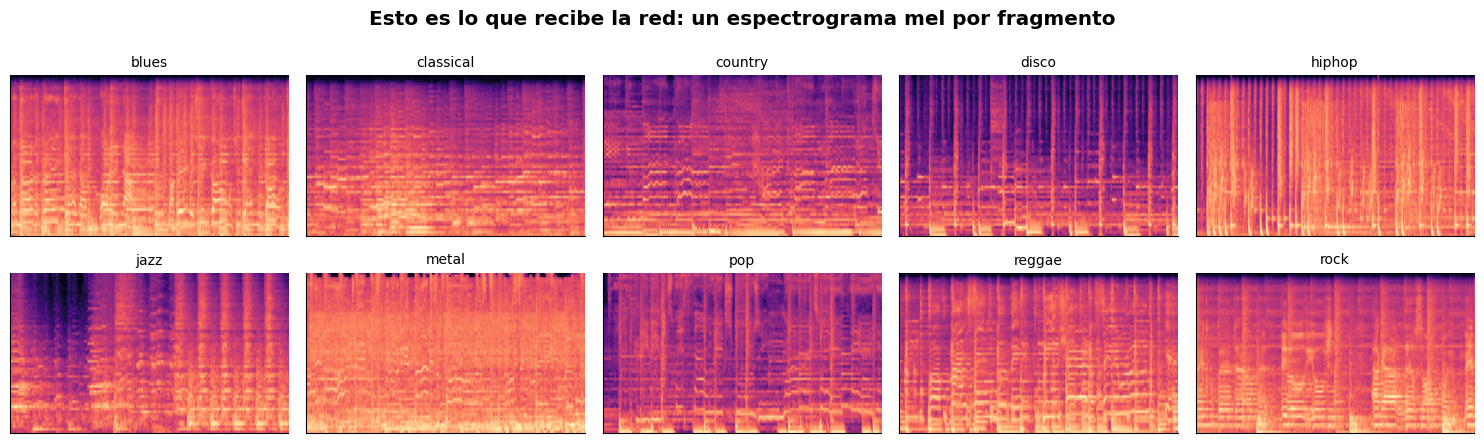

In [ ]:
N_MEL = 64

def banco_mel(n_canales, n_fft=1024, sr=SR):
    fbins = np.fft.rfftfreq(n_fft, 1/sr)
    fc = centros_mel(n_canales, 50, sr/2 - 100, sr)
    med = np.sqrt(fc[:-1]*fc[1:])
    lo = np.concatenate([[fc[0]**2/med[0]], med]); hi = np.concatenate([med, [sr/2]])
    W = np.zeros((n_canales, len(fbins)))
    for i, (l, c, h) in enumerate(zip(lo, fc, hi)):
        W[i] = np.clip(np.minimum((fbins-l)/max(c-l,1e-9), (h-fbins)/max(h-c,1e-9)), 0, None)
        if W[i].sum() > 0: W[i] /= W[i].sum()
    return W, fc

W_MEL, FC_MEL = banco_mel(N_MEL)

def mel_patch(y):
    M = np.log(W_MEL @ stft_mag(y) + 1e-5)
    return ((M - M.mean()) / (M.std() + 1e-8)).astype(np.float32)

X = np.stack([mel_patch(y) for y, _ in AUDIOS])[:, None, :, :]
Y = np.array([clases.index(g) for g in ETIQ])
print("Entrada:", X.shape, "→ (fragmentos, 1, canales mel, tramas)")

rng = np.random.default_rng(0)
idx = rng.permutation(len(X)); corte = int(0.75 * len(X))
tr, te = idx[:corte], idx[corte:]
Xtr = torch.tensor(X[tr]); Ytr = torch.tensor(Y[tr])
Xte = torch.tensor(X[te]); Yte = torch.tensor(Y[te])
print(f"entrenamiento: {len(tr)} | prueba: {len(te)}")

# Un ejemplo de cada clase, tal como lo ve la red
fig, axs = plt.subplots(2, (len(clases)+1)//2, figsize=(15, 4.5))
for ax, c in zip(axs.ravel(), clases):
    j = int(np.where(ETIQ == c)[0][0])
    ax.imshow(X[j, 0], aspect="auto", origin="lower", cmap="magma")
    ax.set_title(c, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
for ax in axs.ravel()[len(clases):]: ax.axis("off")
plt.suptitle("Esto es lo que recibe la red: un espectrograma mel por fragmento",
             fontweight="bold")
plt.tight_layout(); plt.show()

### La arquitectura

Inspirada en la de auto-tagging del tutorial de Peeters (ISMIR 2024), **no** una
réplica. Lo que toma de ahí es el principio de diseño: una convolución cuyo kernel
abarca **toda** la altura del espectrograma, de modo que colapsa la frecuencia de
un golpe, y de ahí en adelante solo se modela el tiempo.

Es el linaje estándar en auto-tagging desde Choi y Pons (2016), y se aparta de una
CNN de imágenes, que trataría frecuencia y tiempo como dos ejes espaciales
equivalentes. En un espectrograma no lo son: moverse en el tiempo es el mismo
evento más tarde; moverse en frecuencia es otra nota.

Diferencias con el original: sin padding allá; su cabeza aplica los lineales sobre
el eje temporal en vez de promediarlo; 128 bandas contra nuestras 64; parches
solapados de 64 tramas contra nuestro fragmento único por pista.

parámetros: 94,450
Representación interna: (999, 60)
entrenamiento=600 | validación=149 | prueba=250
época 15 — validación 0.523 | prueba 0.520
época 30 — validación 0.570 | prueba 0.496
época 45 — validación 0.423 | prueba 0.452
época 60 — validación 0.510 | prueba 0.524

Entrenamiento terminado.
                   ¿QUÉ TAN BIEN CLASIFICA?                   
  Acierta                           57.2 % de las veces
  Adivinando al azar acertaría      10.0 %   (10 clases)
  → es 5.7 veces mejor que adivinar

  Se entrenó 600 fragmentos; nunca vio los 250 de prueba.
  Época usada: 58 de 60, elegida por su desempeño
  en VALIDACIÓN (un trozo apartado del entrenamiento).
--------------------------------------------------------------
  Nota metodológica: en otra época llegó a tocar 61.2 % sobre la
  prueba. Ese número NO se reporta. Elegir la época mirando el
  examen es estudiar con el examen: infla el resultado y arruina
  la comparación contra el modelo preentrenado de la Parte 4.


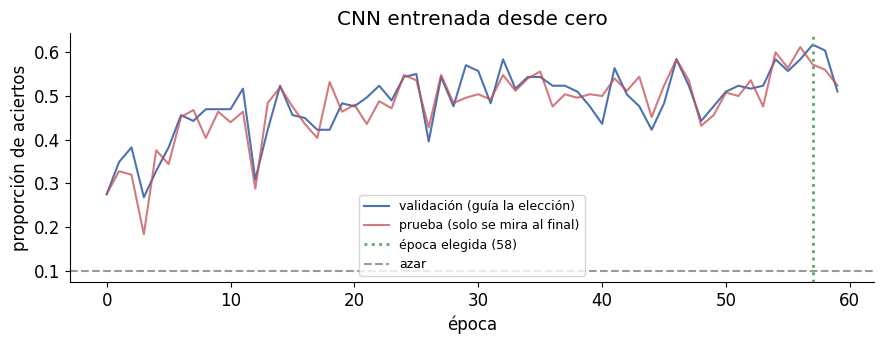

In [ ]:
class CNNAutoTagging(nn.Module):
    def __init__(self, n_mel, n_clases, c_frec=80, c_tiempo=60, oculta=128):
        super().__init__()
        self.norm_ent = nn.LayerNorm(n_mel)
        self.col_frec = nn.Conv2d(1, c_frec, kernel_size=(n_mel, 5), padding=(0, 2))
        self.n0 = nn.LayerNorm(c_frec)
        self.t1 = nn.Sequential(nn.Conv1d(c_frec,   c_tiempo, 5, padding=2), nn.MaxPool1d(3, 3))
        self.t2 = nn.Sequential(nn.Conv1d(c_tiempo, c_tiempo, 5, padding=2), nn.MaxPool1d(3, 3))
        self.n1, self.n2 = nn.LayerNorm(c_tiempo), nn.LayerNorm(c_tiempo)
        self.act = nn.LeakyReLU()
        self.cabeza = nn.Sequential(
            nn.Linear(c_tiempo, oculta), nn.BatchNorm1d(oculta), nn.LeakyReLU(),
            nn.Linear(oculta,   oculta), nn.BatchNorm1d(oculta), nn.LeakyReLU(),
            nn.Linear(oculta, n_clases))

    def _ln(self, capa, z): return self.act(capa(z.transpose(1,2)).transpose(1,2))

    def tronco(self, z):
        """Representación interna: lo que la red construye ANTES de decidir."""
        z = self.norm_ent(z.transpose(2,3)).transpose(2,3)
        z = self.col_frec(z).squeeze(2)
        z = self._ln(self.n0, z)
        z = self._ln(self.n1, self.t1(z))
        z = self._ln(self.n2, self.t2(z))
        return z.mean(-1)

    def forward(self, z): return self.cabeza(self.tronco(z))

modelo = CNNAutoTagging(X.shape[2], len(clases)).to(DEV)
print("parámetros:", f"{sum(p.numel() for p in modelo.parameters()):,}")

def representacion(M, Xs, lote=64):
    M.eval(); H = []
    with torch.no_grad():
        for i in range(0, len(Xs), lote):
            H.append(M.tronco(Xs[i:i+lote].to(DEV)).cpu().numpy())
    return np.concatenate(H)

# Guardamos su espacio interno ANTES de entrenar, para comparar después
Xall = torch.tensor(X)
H_ANTES = representacion(modelo, Xall)
print("Representación interna:", H_ANTES.shape)

# --- Validación separada del test ------------------------------------------
# La época se elige mirando VALIDACIÓN, nunca la prueba. La validación sale de
# 'tr', así que la Parte 4 sigue entrenando en 'tr' y evaluando en 'te'.
g = torch.Generator().manual_seed(0)
orden = torch.randperm(len(Xtr), generator=g)
n_val = max(8, int(0.2 * len(Xtr)))
i_val, i_tr = orden[:n_val], orden[n_val:]
Xva, Yva = Xtr[i_val], Ytr[i_val]
Xen, Yen = Xtr[i_tr],  Ytr[i_tr]
print(f"entrenamiento={len(Xen)} | validación={len(Xva)} | prueba={len(Xte)}")

opt, perdida = torch.optim.Adam(modelo.parameters(), lr=1e-3), nn.CrossEntropyLoss()

def evaluar(Xs, Ys, lote=64):
    modelo.eval(); ok = 0
    with torch.no_grad():
        for i in range(0, len(Xs), lote):
            ok += (modelo(Xs[i:i+lote].to(DEV)).argmax(1).cpu() == Ys[i:i+lote]).sum().item()
    return ok / len(Xs)

h_val, h_test, mejor_val, ACC_CNN, ep_sel = [], [], -1.0, 0.0, 0
mejor_estado = copy.deepcopy(modelo.state_dict())

for epoca in range(60):
    modelo.train()
    perm = torch.randperm(len(Xen), generator=g)
    for i in range(0, len(Xen), 32):
        b = perm[i:i+32]
        if len(b) < 2: continue
        opt.zero_grad()
        perdida(modelo(Xen[b].to(DEV)), Yen[b].to(DEV)).backward()
        opt.step()
    av, at = evaluar(Xva, Yva), evaluar(Xte, Yte)
    h_val.append(av); h_test.append(at)
    if av > mejor_val:
        mejor_val, ACC_CNN, ep_sel = av, at, epoca
        mejor_estado = copy.deepcopy(modelo.state_dict())
    if epoca % 15 == 14:
        print(f"época {epoca+1:2d} — validación {av:.3f} | prueba {at:.3f}")

modelo.load_state_dict(mejor_estado)     # restaura la época elegida
print("\nEntrenamiento terminado.")

azar = 1 / len(clases)
ancho = 62
print("=" * ancho)
print("¿QUÉ TAN BIEN CLASIFICA?".center(ancho))
print("=" * ancho)
print(f"  Acierta                          {ACC_CNN*100:5.1f} % de las veces")
print(f"  Adivinando al azar acertaría     {azar*100:5.1f} %   ({len(clases)} clases)")
print(f"  → es {ACC_CNN/azar:.1f} veces mejor que adivinar")
print()
print(f"  Se entrenó {len(Xen)} fragmentos; nunca vio los {len(Xte)} de prueba.")
print(f"  Época usada: {ep_sel+1} de {len(h_val)}, elegida por su desempeño")
print("  en VALIDACIÓN (un trozo apartado del entrenamiento).")
print("-" * ancho)
print("  Nota metodológica: en otra época llegó a tocar "
      f"{max(h_test)*100:.1f} % sobre la")
print("  prueba. Ese número NO se reporta. Elegir la época mirando el")
print("  examen es estudiar con el examen: infla el resultado y arruina")
print("  la comparación contra el modelo preentrenado de la Parte 4.")
print("=" * ancho)

plt.figure(figsize=(9, 3.6))
plt.plot(h_val,  color="#4C72B0", label="validación (guía la elección)")
plt.plot(h_test, color="#C44E52", label="prueba (solo se mira al final)", alpha=.75)
plt.axvline(ep_sel, color="#55A868", ls=":", lw=2, label=f"época elegida ({ep_sel+1})")
plt.axhline(azar, color="#999", ls="--", label="azar")
plt.xlabel("época"); plt.ylabel("proporción de aciertos")
plt.title("CNN entrenada desde cero"); plt.legend(fontsize=9)
plt.tight_layout(); plt.show()

### Pero "acierta N veces más que al azar" no dice **qué** aprendió

Un número agregado no distingue entre una red que captó algo musical y una que
encontró un atajo. Tres formas de mirar adentro.

#### 1. Su espacio interno se reorganizó

La red construye una representación propia antes de decidir. Comparemos esa
representación **antes** y **después** del entrenamiento, proyectada a dos
dimensiones. Nadie le dijo dónde colocar cada género: la geometría es consecuencia
de haber aprendido.

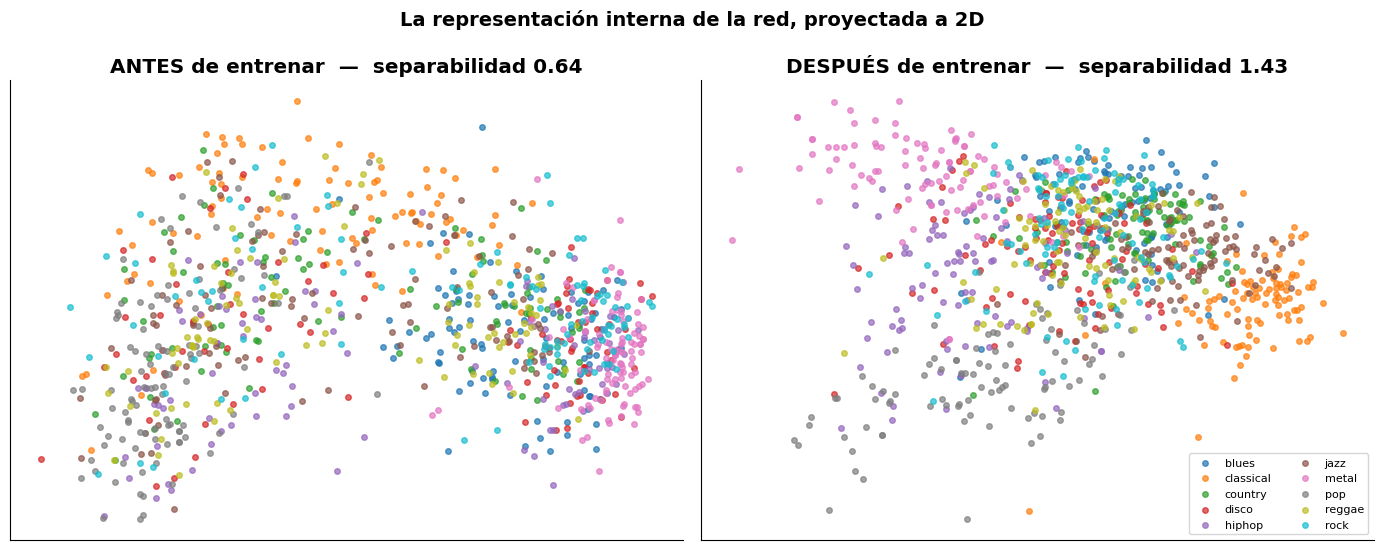

In [ ]:
from sklearn.decomposition import PCA

H_DESPUES = representacion(modelo, Xall)

def separabilidad(P, etq):
    """Varianza entre clases / varianza dentro de clase. Mayor = mejor separado."""
    glob = P.mean(0)
    entre = sum(len(P[etq==k]) * ((P[etq==k].mean(0)-glob)**2).sum()
                for k in np.unique(etq))
    dentro = sum(((P[etq==k] - P[etq==k].mean(0))**2).sum() for k in np.unique(etq))
    return entre / dentro

fig, axs = plt.subplots(1, 2, figsize=(14, 5.6), sharex=False)
for ax, (H, titulo) in zip(axs, [(H_ANTES, "ANTES de entrenar"),
                                 (H_DESPUES, "DESPUÉS de entrenar")]):
    P = PCA(n_components=2).fit_transform(H)
    for c in clases:
        m = ETIQ == c
        ax.scatter(P[m,0], P[m,1], s=16, alpha=.7, label=c)
    ax.set_title(f"{titulo}  —  separabilidad {separabilidad(P, Y):.2f}",
                 fontweight="bold")
    ax.set_xticks([]); ax.set_yticks([])
axs[1].legend(fontsize=8, ncol=2, loc="best")
plt.suptitle("La representación interna de la red, proyectada a 2D",
             fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

#### 2. Sus errores tienen sentido musical

Si la red hubiera memorizado ruido, sus errores estarían repartidos al azar.
Veamos si confunde géneros que **de verdad se parecen**.

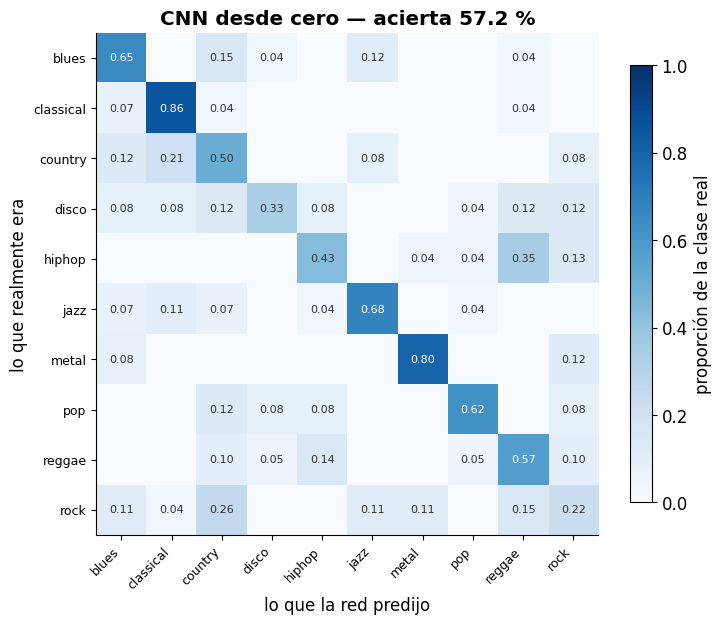

Las confusiones más frecuentes:
  'hiphop' lo clasificó como 'reggae'  (8 veces)
  'rock' lo clasificó como 'country'  (7 veces)
  'country' lo clasificó como 'classical'  (5 veces)
  'blues' lo clasificó como 'country'  (4 veces)

Si estas parejas te suenan razonables como oyente,
la red aprendió algo musical y no un atajo.


In [ ]:
from sklearn.metrics import confusion_matrix

modelo.eval(); _p = []
with torch.no_grad():
    for i in range(0, len(Xte), 64):
        _p.append(modelo(Xte[i:i+64].to(DEV)).argmax(1).cpu())
PRED_CNN = torch.cat(_p).numpy()
Yte_np = Yte.numpy()
et = list(range(len(clases)))

cm = confusion_matrix(Yte_np, PRED_CNN, labels=et).astype(float)
filas = cm.sum(1, keepdims=True)
cmn = np.divide(cm, filas, out=np.zeros_like(cm), where=filas > 0)

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(et); ax.set_xticklabels(clases, rotation=45, ha="right", fontsize=9)
ax.set_yticks(et); ax.set_yticklabels(clases, fontsize=9)
ax.set_xlabel("lo que la red predijo"); ax.set_ylabel("lo que realmente era")
ax.set_title(f"CNN desde cero — acierta {ACC_CNN*100:.1f} %", fontweight="bold")
for i in et:
    for j in et:
        if cmn[i,j] > 0.01:
            ax.text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center", fontsize=8,
                    color="white" if cmn[i,j] > 0.5 else "#333")
fig.colorbar(im, ax=ax, shrink=.8, label="proporción de la clase real")
plt.tight_layout(); plt.show()

cm_e = confusion_matrix(Yte_np, PRED_CNN, labels=et).copy()
np.fill_diagonal(cm_e, 0)
print("Las confusiones más frecuentes:")
for k in range(4):
    i, j = np.unravel_index(cm_e.argmax(), cm_e.shape)
    if cm_e[i, j] == 0: break
    veces = int(cm_e[i, j])
    print(f"  '{clases[i]}' lo clasificó como '{clases[j]}'  "
          f"({veces} {'vez' if veces == 1 else 'veces'})")
    cm_e[i, j] = 0
print("\nSi estas parejas te suenan razonables como oyente,")
print("la red aprendió algo musical y no un atajo.")

#### 3. ¿En qué parte del espectro se apoya?

Tapamos un grupo de canales mel a la vez y medimos cuánto cae el acierto. Donde
más cae, más depende la red de esa región. **No miramos los pesos: medimos
comportamiento**, que es lo único que de verdad indica en qué se apoya.

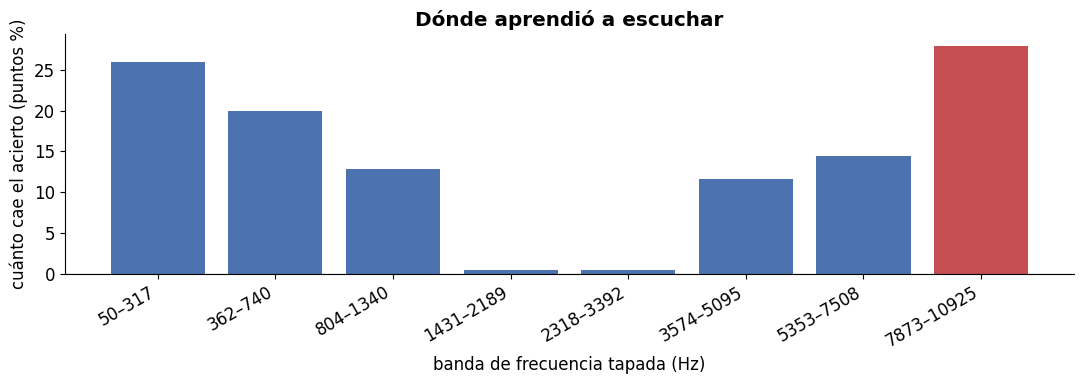

Acierto sin tapar nada: 57.2 %
La banda más crítica es 7873–10925 Hz: taparla cuesta 28.0 puntos.

Nadie le dijo que mirara ahí. Lo encontró sola.


In [ ]:
base = evaluar(Xte, Yte)
ANCHO_B = 8
caidas, etiq_b = [], []
relleno = float(Xte.mean())
for ini in range(0, X.shape[2], ANCHO_B):
    Xo = Xte.clone(); Xo[:, :, ini:ini+ANCHO_B, :] = relleno
    caidas.append(base - evaluar(Xo, Yte))
    etiq_b.append(f"{FC_MEL[ini]:.0f}–{FC_MEL[min(ini+ANCHO_B, len(FC_MEL))-1]:.0f}")

plt.figure(figsize=(11, 4))
colores = ["#C44E52" if c == max(caidas) else "#4C72B0" for c in caidas]
plt.bar(range(len(caidas)), [c*100 for c in caidas], color=colores)
plt.xticks(range(len(caidas)), etiq_b, rotation=30, ha="right")
plt.axhline(0, color="#333", lw=.8)
plt.xlabel("banda de frecuencia tapada (Hz)")
plt.ylabel("cuánto cae el acierto (puntos %)")
plt.title("Dónde aprendió a escuchar", fontweight="bold")
plt.tight_layout(); plt.show()

k = int(np.argmax(caidas))
print(f"Acierto sin tapar nada: {base*100:.1f} %")
print(f"La banda más crítica es {etiq_b[k]} Hz: taparla cuesta "
      f"{caidas[k]*100:.1f} puntos.")
print("\nNadie le dijo que mirara ahí. Lo encontró sola.")

Eso es "aprender sola", en concreto: **reorganizó su espacio interno**, sus
**errores siguen parecidos musicales**, y **se apoya en regiones específicas del
espectro** que nadie le señaló.

Pero fíjate en lo que **no** aprendió: el espectrograma mel de la entrada.
Ese se lo dimos hecho.

## Parte 4 — Tercera generación: modelos fundacionales

Hoy ni siquiera hace falta entrenar. Un modelo preentrenado con miles de horas de
audio **sin etiquetas** ya produce representaciones útiles. Le pedimos sus
embeddings y encima ponemos un clasificador lineal.

Esa técnica se llama **linear probe**, sonda lineal: congelamos el modelo
preentrenado, le pedimos sus representaciones, y encima ponemos el clasificador
más simple que existe. Si con eso basta para separar los géneros, es que el
trabajo ya estaba hecho — la información ya estaba ahí, ordenada.

preprocessor_config.json:   0%|          | 0.00/211 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.82k [00:00<?, ?B/s]

configuration_MERT.py:   0%|          | 0.00/5.34k [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/m-a-p/MERT-v1-95M:
- configuration_MERT.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_MERT.py:   0%|          | 0.00/18.0k [00:00<?, ?B/s]

...

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  378MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] `use_return_dict` is deprecated! Use `return_dict` instead!


Modelo cargado: m-a-p/MERT-v1-95M
--- front-end de m-a-p/MERT-v1-95M ---
  feature_size                 1
  sampling_rate                24000
Embeddings: (999, 768) → (fragmentos, dimensión)   [48 s]


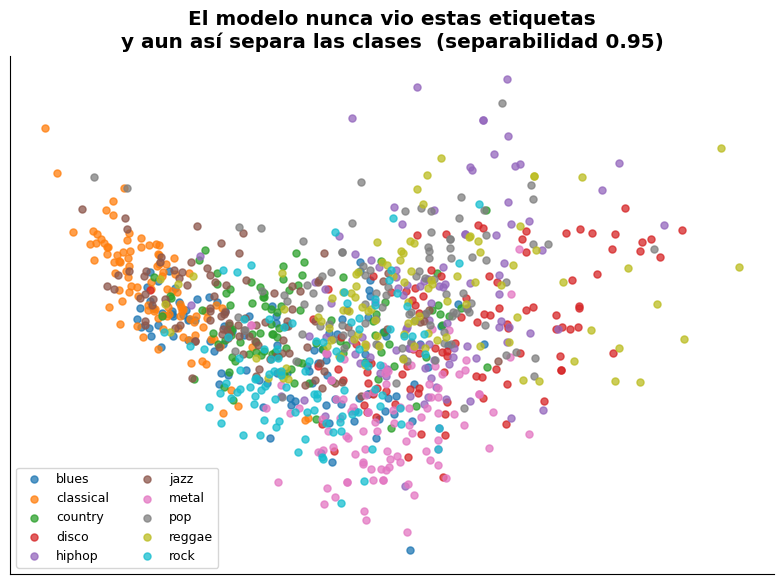

CNN entrenada desde cero      :  57.2 %
Sonda lineal sobre embeddings :  74.4 %
Azar                          :  10.0 %


In [ ]:
from transformers import AutoModel, AutoFeatureExtractor

CANDIDATOS = [("m-a-p/MERT-v1-95M", True),                          # fundacional de música
              ("MIT/ast-finetuned-audioset-10-10-0.4593", False)]   # respaldo: AST

modelo_pre = fe = NOMBRE = None
for nombre, remoto in CANDIDATOS:
    try:
        if remoto:
            import subprocess, sys
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", "nnAudio"],
                           check=False)
        fe = AutoFeatureExtractor.from_pretrained(nombre, trust_remote_code=remoto)
        modelo_pre = AutoModel.from_pretrained(nombre, trust_remote_code=remoto).to(DEV).eval()
        NOMBRE = nombre; print("Modelo cargado:", nombre); break
    except Exception as e:
        print(f"[aviso] falló {nombre}: {type(e).__name__}")

assert modelo_pre is not None, "Ningún modelo preentrenado pudo cargarse."

# ¿Cuál es el front-end de este modelo de última generación?
# No lo afirmamos: se lo preguntamos.
cfg = fe.to_dict()
print(f"--- front-end de {NOMBRE} ---")
for k, v in cfg.items():
    if any(s in k.lower() for s in ["mel", "fft", "hop", "window", "sampling",
                                    "num_bins", "feature_size", "stride"]):
        print(f"  {k:28s} {v}")

import librosa
SR_MODELO = cfg.get("sampling_rate", 24000)

def embeddings(audios, lote=8):
    salida = []
    for i in range(0, len(audios), lote):
        trozo = [librosa.resample(y, orig_sr=s, target_sr=SR_MODELO) if s != SR_MODELO else y
                 for y, s in audios[i:i+lote]]
        ent = fe(trozo, sampling_rate=SR_MODELO, return_tensors="pt", padding=True)
        ent = {k: v.to(DEV) for k, v in ent.items()}
        with torch.no_grad():
            h = modelo_pre(**ent).last_hidden_state
        salida.append(h.mean(1).cpu().numpy())
    return np.concatenate(salida)

t0 = time.time()
E = embeddings(AUDIOS)
print(f"Embeddings: {E.shape} → (fragmentos, dimensión)   [{time.time()-t0:.0f} s]")

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Guardia: 'tr'/'te' deben seguir siendo los índices enteros de la celda de datos.
def _indices(v, nombre):
    a = np.asarray(v)
    if a.ndim != 1 or not np.issubdtype(a.dtype, np.integer):
        raise RuntimeError(
            f"'{nombre}' no son índices enteros (dtype={a.dtype}). Se sobrescribió "
            "al re-ejecutar una celda anterior. Vuelve a correr la celda que "
            "construye X, Y, tr y te, y repite esta.")
    return a
tr = _indices(tr, "tr"); te = _indices(te, "te")
assert len(tr) + len(te) == len(E), "Los índices no cubren todos los embeddings."

esc = StandardScaler().fit(E[tr])        # ajustado SOLO con entrenamiento
Ez  = esc.transform(E)

P = PCA(n_components=2).fit(Ez[tr]).transform(Ez)
plt.figure(figsize=(8, 6))
for c in clases:
    m = ETIQ == c
    plt.scatter(P[m,0], P[m,1], label=c, s=26, alpha=.75)
plt.legend(fontsize=9, ncol=2); plt.xticks([]); plt.yticks([])
plt.title(f"El modelo nunca vio estas etiquetas\ny aun así separa las clases  "
          f"(separabilidad {separabilidad(P, Y):.2f})", fontweight="bold")
plt.tight_layout(); plt.show()

# Misma cantidad de datos etiquetados que la CNN: a ella le apartamos un 20 %
# para validación, así que la sonda entrena con ESOS mismos ejemplos.
i_glob     = tr[i_tr.numpy()]
sonda      = LogisticRegression(max_iter=2000).fit(Ez[i_glob], Y[i_glob])
PRED_SONDA = sonda.predict(Ez[te])
ACC_SONDA  = (PRED_SONDA == Y[te]).mean()

print(f"CNN entrenada desde cero      : {ACC_CNN*100:5.1f} %")
print(f"Sonda lineal sobre embeddings : {ACC_SONDA*100:5.1f} %")
print(f"Azar                          : {azar*100:5.1f} %")

### Los dos, lado a lado

Mismo conjunto de prueba. No solo cuánto fallan: **en qué**.

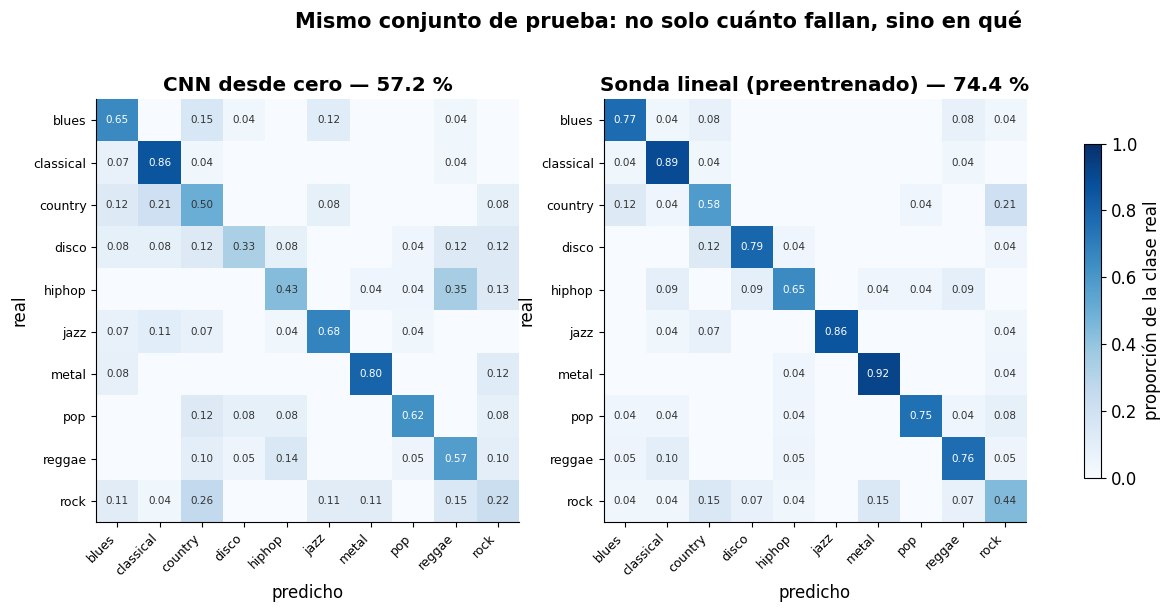

CNN    — confusión más frecuente: 'hiphop' → 'reggae' (8 veces)
Sonda  — confusión más frecuente: 'country' → 'rock' (5 veces)


In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(15, 6.2))
for ax, (pred, titulo, acc) in zip(axs, [
        (PRED_CNN,   "CNN desde cero",              ACC_CNN),
        (PRED_SONDA, "Sonda lineal (preentrenado)", ACC_SONDA)]):
    cm = confusion_matrix(Yte_np, pred, labels=et).astype(float)
    filas = cm.sum(1, keepdims=True)
    cmn = np.divide(cm, filas, out=np.zeros_like(cm), where=filas > 0)
    im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(et); ax.set_xticklabels(clases, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(et); ax.set_yticklabels(clases, fontsize=9)
    ax.set_xlabel("predicho"); ax.set_ylabel("real")
    ax.set_title(f"{titulo} — {acc*100:.1f} %", fontweight="bold")
    for i in et:
        for j in et:
            if cmn[i,j] > 0.01:
                ax.text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center", fontsize=7.5,
                        color="white" if cmn[i,j] > 0.5 else "#333")
fig.colorbar(im, ax=axs, shrink=.7, label="proporción de la clase real")
plt.suptitle("Mismo conjunto de prueba: no solo cuánto fallan, sino en qué",
             fontsize=15, fontweight="bold")
plt.show()

for nombre, pred in [("CNN", PRED_CNN), ("Sonda", PRED_SONDA)]:
    c_ = confusion_matrix(Yte_np, pred, labels=et).copy(); np.fill_diagonal(c_, 0)
    i, j = np.unravel_index(c_.argmax(), c_.shape)
    print(f"{nombre:6s} — confusión más frecuente: "
          f"'{clases[i]}' → '{clases[j]}' ({c_[i,j]} veces)")

### ¿Y si a la red solo le faltaban datos?

La sonda le gana por mucho. Antes de concluir nada hay que descartar la
explicación aburrida: que la CNN perdiera solo por haber entrenado con pocos
ejemplos. Lo medimos entrenándola con la cuarta parte, la mitad y el total de
los datos disponibles.

Si la curva sigue subiendo al llegar al 100 %, los datos son una restricción
activa. Si se aplana lejos de la línea verde, más etiquetas no habrían cerrado
la brecha.

   25 % de los datos ( 150 fragmentos) → prueba  44.0 %
   50 % de los datos ( 300 fragmentos) → prueba  50.0 %
  100 % de los datos ( 600 fragmentos) → prueba  52.8 %


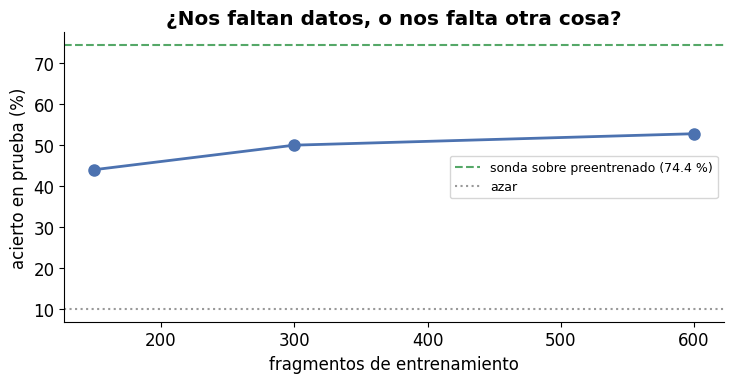

In [ ]:
# --- ¿Es el tamaño del dataset lo que limita? -------------------------------
def entrenar_con(fraccion, epocas=40, semilla=0):
    gg = torch.Generator().manual_seed(semilla)
    n = max(32, int(fraccion * len(Xen)))
    sub = torch.randperm(len(Xen), generator=gg)[:n]
    M = CNNAutoTagging(X.shape[2], len(clases)).to(DEV)
    o = torch.optim.Adam(M.parameters(), lr=1e-3)
    lf = nn.CrossEntropyLoss()
    def ev(Xs, Ys):
        M.eval(); ok = 0
        with torch.no_grad():
            for i in range(0, len(Xs), 64):
                ok += (M(Xs[i:i+64].to(DEV)).argmax(1).cpu() == Ys[i:i+64]).sum().item()
        return ok / len(Xs)
    mejor, acc = -1.0, 0.0
    for _ in range(epocas):
        M.train()
        perm = torch.randperm(n, generator=gg)
        for i in range(0, n, 32):
            b = sub[perm[i:i+32]]
            if len(b) < 2: continue
            o.zero_grad(); lf(M(Xen[b].to(DEV)), Yen[b].to(DEV)).backward(); o.step()
        av = ev(Xva, Yva)
        if av > mejor: mejor, acc = av, ev(Xte, Yte)
    return n, acc

fracs = [0.25, 0.50, 1.00]
res = [entrenar_con(f) for f in fracs]
for (n, a), f in zip(res, fracs):
    print(f"  {f*100:3.0f} % de los datos ({n:4d} fragmentos) → prueba {a*100:5.1f} %")

plt.figure(figsize=(7.5, 4))
plt.plot([n for n, _ in res], [a*100 for _, a in res], "o-", lw=2, color="#4C72B0", ms=8)
plt.axhline(ACC_SONDA*100, color="#55A868", ls="--",
            label=f"sonda sobre preentrenado ({ACC_SONDA*100:.1f} %)")
plt.axhline(azar*100, color="#999", ls=":", label="azar")
plt.xlabel("fragmentos de entrenamiento"); plt.ylabel("acierto en prueba (%)")
plt.title("¿Nos faltan datos, o nos falta otra cosa?", fontweight="bold")
plt.legend(fontsize=9); plt.tight_layout(); plt.show()

## Parte 5 — El puente a nuestra investigación

Recapitulemos qué se automatizó a lo largo de la charla:

| | representación | clasificador |
|---|---|---|
| **Primera generación** | diseñada a mano | diseñado a mano |
| **Segunda generación** | **diseñada a mano** | aprendido |
| **Tercera generación** | **diseñada a mano** | aprendido sin etiquetas |

La columna de la izquierda **no se movió**. Lo verificamos en vivo: la celda que
imprime la configuración del modelo preentrenado muestra que sigue habiendo un
banco de filtros en la entrada, y sigue siendo mel — la escala que salió de
experimentos psicoacústicos de **1937**.

Automatizamos todo lo demás. El front-end es la última pieza artesanal que nadie
desmontó.

Y fíjate en el detalle que vimos en la Parte 3: cuando medimos **dónde** aprendió
a escuchar la red, la respuesta vino expresada en canales mel — porque el eje se
lo dimos nosotros. No podía apoyarse en una región que su front-end no le
entregaba.

**Nuestro trabajo en el IIMAS pregunta lo que esa tabla deja abierto:** ¿la elección del
front-end auditivo es preprocesamiento neutro, o decide qué evidencia acústica
queda disponible para el modelo? Y en transcripción musical automática lo medimos
no por accuracy, sino por dónde queda localizable la evidencia cuando el modelo
se equivoca.

---

### Para seguirle

- `librosa`, `torchaudio` — espectrogramas, bancos de filtros, features
- `nnAudio` — bancos de filtros **entrenables** dentro de la red
- GTZAN, MAPS, Bach10 — datasets de entrada (GTZAN tiene errores de etiqueta conocidos)
- ISMIR — la conferencia del área, actas y tutoriales abiertos

### Créditos

Arquitectura inspirada en el tutorial *Deep Learning 101 for Audio-based MIR*
de G. Peeters (ISMIR 2024).
GTZAN: G. Tzanetakis y P. Cook (2002).